In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Stochastic Analysis on the SARS-CoV-2 Genomic Data

In [ ]:
# imports

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

import pandas as pd
import statistics as stats
from math import gamma

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy import interpolate

In [ ]:
# Set parameter values
q = 11
N = 2**q + 1
M = 2*N - 2
dt = 1.                               # size of time step
sd = np.sqrt(dt)                      # standard deviation
t = dt*np.arange(N)                   # time

In [ ]:
def fbc(n,G):
    return ((n+1)**G + np.abs(n-1)**G - 2*n**G)/2.

# Computes sqrt(lambda)
def lambda_func(H,N):
    M = 2*N - 2
    C = np.zeros(M)
    G = 2*H
    for i in np.arange(N):
        C[i] = fbc(i,G) # fill in first N out of M values of C (i=0 to N-1)
    C[N:] = C[1:N-1][::-1]
    return np.real(np.fft.fft(C))**0.5

# Computes the displacement of samples
def get_displacements(x,tau):

  '''
  inputs: x: fBm samples (1-d array), tau: lag time (float)
  returns: dx: displacements (1-d array)

  '''

  delta = np.round(tau/dt).astype(int)
  nn = len(x)

  # initialize array to store displacements
  # Note: The size n is larger than the actual number of values to be stored
  # values are initialized to NaN (which are not included in the PDF calculation)
  dx = np.empty((nn))*np.nan

  # get truncated copy of x, ending in initial data point of the last pair
  x_trunc = x[:-1*delta]

  # get shifted copy of x, starting from end data point of the first pair
  x_shift = x[delta:]

  # get displacements
  dx = x_shift - x_trunc

  return dx

# Computes and plots PDF of Fractional Brownian motion
def plot_pdf_fbm(dx,tau,H):

  '''
  inputs: x: dx: displacements (1-d array), tau: lag time (float),
          H: Hurst parameter (float)
  returns: none

  '''
  # Compute msd of fBm
  msd = (tau**(2*H))/(2*H*(gamma(H+0.5))**2)

  # Generates normalized Gaussian distribution with mean = 0 and sd = sqrt(MSD)
  xx_mean = 0.
  xx_sd = np.sqrt(msd)
  xx = np.linspace(-5, 5)*xx_sd # gridded points from -5 to 5 in units of sd
  yy = norm.pdf(xx, xx_mean, xx_sd)

  # Plot Gaussian distribution
  plt.plot(xx, yy, '-', color=label_colors[j], label=str("analytic fBm ($H$ = " + str(H) + ")"), lw=1.5)

#-------------------------------------------------------------------------------
# In case normalization in matplotlib malfunctions, use this code instead
# to compute histograms
  #hist, bins = np.histogram(dx, bins=10, density=False)
  #hist_norm = hist/hist.sum()   # normalize hist
  #bin_centers = (bins[:-1] + bins[1:]) / 2
  #plt.bar(bin_centers, hist_norm, width=(bins[1]-bins[0]), label="BM")
  #plt.xlabel("Delta x")
  #plt.ylabel("PDF")
#-------------------------------------------------------------------------------

# Computes MSD
def get_msd(x, tau):
  '''
  inputs: x: fBm samples (1-d array), tau: lag time (float)
  returns: msd: msd of fBm samples (1-d array)

  '''
  delta = np.round(tau/dt).astype(int)

  # computes displacements
  dx = get_displacements(x,tau)

  dx_sum = np.nansum(dx**2) # returns sum treating NaNs as zero

  # computes msd
  msd = dx_sum/(N-delta)

  return msd

# SARS-CoV-2 Genomic Data


## I. Extraction of occurrence distance vs. occurrence number from sequence data

The raw data consists of a long string of nucleotides A, C, T, and G. We can think of these nucleotides as being four different samples and we will treat them as such in this analysis. In the following subsection, we will do the following:

1. divide the sequence into single-nucleotide strings
2. compute nucleotide positions in the sequence by recording the position in which they appear in the sequence
3. compute nucleotide distances by subtracting adjacent nucleotide positions
4. plot nucleotide distances against occurrence numbers (instance in which nucleotide occurs in the sequence)

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/305/genomic.fna"
#-------------------------------------------------------------------------------
# Reads fna file containing sequence and returns the sequence as a single string
def read_fasta(file_path):
    sequences = {}
    current_sequence = None

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith('>'):
                if current_sequence is not None:
                    sequences[header] = current_sequence
                header = line[1:]
                current_sequence = ''
            else:
                current_sequence += line

        # Add the last sequence
        sequences[header] = current_sequence

    return sequences

sequences = read_fasta(file_path)

# Accessing the sequences
for header, sequence in sequences.items():
    print(f'Header: {header}')
    print(f'Sequence: {sequence}')

sequence=str(sequence)

#-------------------------------------------------------------------------------
# Divides the sequence into single-nucleotide strings

def divide_string(long_string, chunk_size):
    return [long_string[i:i+chunk_size] for i in range(0, len(long_string), chunk_size)]

long_string = sequence
chunk_size = 1
sequence = divide_string(long_string, chunk_size)
#print(sequence)
print(np.shape(sequence))
#-------------------------------------------------------------------------------


Header: NC_045512.2 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Sequence: ...
(29903,)


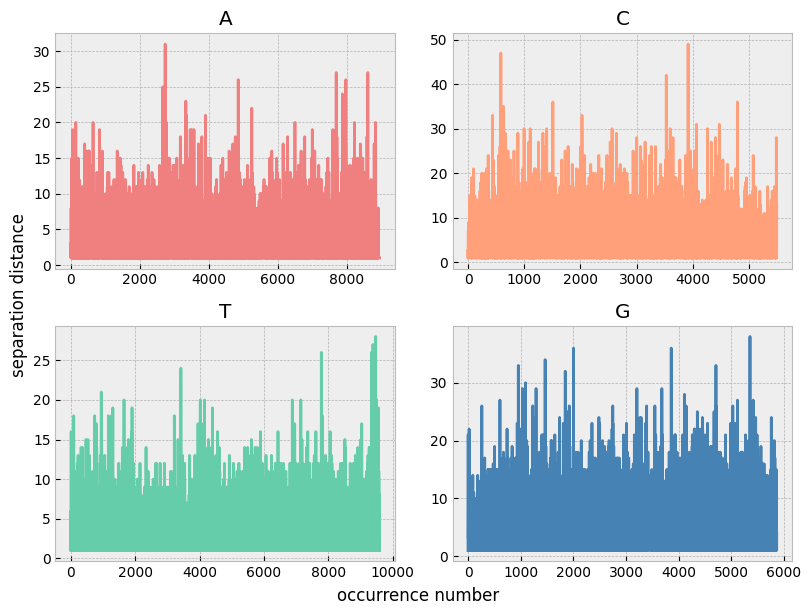

In [ ]:
# Initialize arrays for nucleotide positions
arr_A = []
arr_C = []
arr_T = []
arr_G = []
arr = [arr_A, arr_C, arr_T, arr_G]

# Introduce nucleotide labels
labels = ['A','C','T','G']
label_colors = ['lightcoral', 'lightsalmon', 'mediumaquamarine', 'steelblue']

# Compute nucleotide positions
for i in range(len(sequence)):
  if sequence[i]=='A':
    arr_A.append(i)
  elif sequence[i]=='C':
    arr_C.append(i)
  elif sequence[i]=='T':
    arr_T.append(i)
  else:
    arr_G.append(i)

# Compute distances (x) between adjacent nucleotides
def get_distances(arr):
  n_arr = len(arr)
  df = np.zeros(n_arr-1)
  for j in range(n_arr-1):
    df[j] = arr[j+1]-arr[j]
  return df

# Initialize array for distances
df = []

# Implement computation and plotting of distances (x) of adjacent nucleotides
# vs. occurrence number
nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey=False, figsize=(8,6))
fig.text(-0.01, 0.5, 'separation distance', va='center', rotation='vertical',size=12)
fig.text(0.5, -0.01, 'occurrence number', ha = 'center', rotation='horizontal',size=12)

for i in range(len(arr)):
  arr[i] = np.array(arr[i])
  df.append(get_distances(arr[i]))
  plt.subplot(2,2,i+1)
  plt.plot(np.arange(len(df[i])),df[i], '-',color=label_colors[i],lw=2)
  plt.title(labels[i])
plt.tight_layout()
plt.show()

##II. PDFs

We calculate the probability density function for the displacements $\Delta x = x_j-x_i$ for any two points $x_i$ and $x_j$ for different values of the lag, $\Delta = L$.

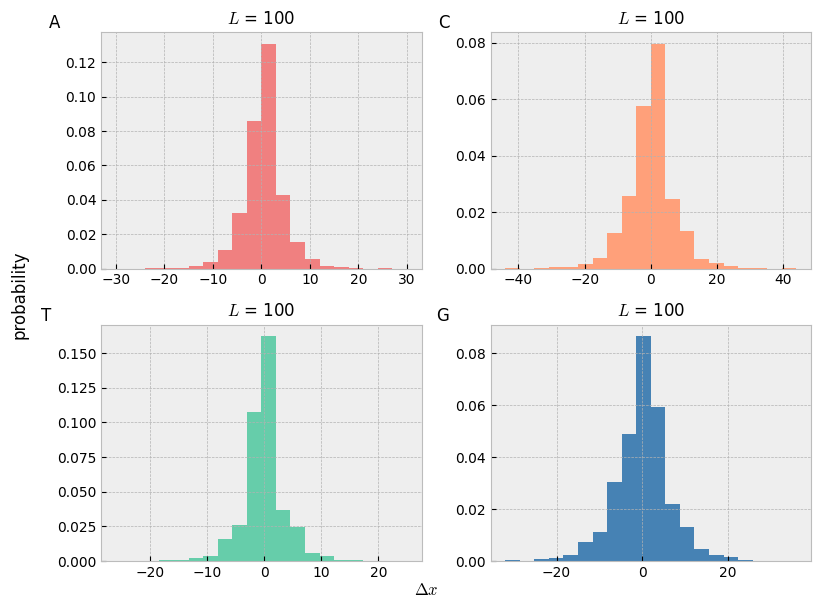

In [ ]:
# set parameters
n_samp=4                                       # no. of samples
tau_vals =np.array([100])            # lag times

# implement code for computation of PDFs for different lag times
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=False, sharey = False, figsize=(8,6))
fig.text(-0.02, 0.5, 'probability', va='center', rotation='vertical',size=12)
fig.text(0.5, 0, r'$\Delta x$', ha = 'center', rotation='horizontal',size=12)

for j in range(n_samp):
  for k in range(len(tau_vals)):
    plt.subplot(nrows,ncols,j+1)
    x = df[j]
    dx = get_displacements(x, tau_vals[k])
    dx = dx[np.isfinite(dx)]
    plt.hist(dx, bins=20, density=True, color=label_colors[j])
    plt.title(r"$L$ = %.0f" % (tau_vals[k]), size=12)
    if k==0:
      plt.ylabel(labels[j], rotation='horizontal', size=12, loc='top')
plt.tight_layout()
plt.show()


## III. MSDs

For the computation of MSDs, we set the lags, $L$ to run from $1$ to $1000$ in increments of $1$.

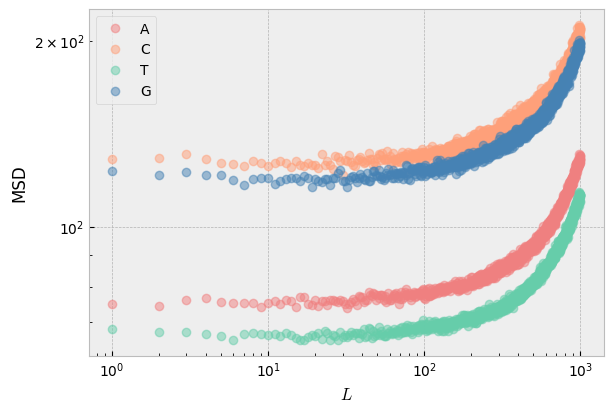

In [ ]:
# set parameters
n_samp = 4
tau_vals =np.arange(1,1e3,1)

# memory functions
def msd_func(x,a,b,c):
  return a*np.exp(b*x) + c

# implement code for computation of MSDs
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey = False, figsize=(6,4))

xpoints = np.zeros(len(tau_vals))
ypoints = np.zeros([n_samp,len(tau_vals)])
for j in range(n_samp):
  for k in range(len(tau_vals)):
    xpoints[k] = tau_vals[k]
    ypoints[j,k] = get_msd(df[j],tau_vals[k])
  plt.plot(xpoints, ypoints[j,:], 'o', label = labels[j], color=label_colors[j], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.xlabel("$L$", size=12)
plt.ylabel("MSD", size=12)
plt.show()


#IV. Memory Functions

### Ordinary Brownian Motion ($H=0.5$)

Memory Function: $$f(L-s) = 1$$

PDF:

$$P(x_L, L; x_0,0)  = \frac{1}{\sqrt{4\pi DL}}\exp\left(\frac{-(x_L-x_0)^2}{4DL}\right)$$

MSD:

$$\text{MSD} = 2DL =  L$$

FPTD:

\begin{align}
f(t) =& -\frac{(x_0-x_c)}{\sqrt{2\pi \cdot \text{MSD}}}\frac{\partial (\text{MSD})}{\partial L}\exp\left[-\frac{(x_0-x_c)^2}{2\cdot \text{MSD}}\right]\\
=& 2H\sqrt{\frac{H\Gamma(H+1/2)^2}{\pi}}\frac{1}{L^{H+1}}(x_c-x_0)\exp\left[-\frac{H\Gamma(H+1/2)^2(x_c-x_0)^2}{L^{2H}}\right]\\
=& \sqrt{\frac{1}{2\pi}}\frac{1}{L^{3/2}}(x_c-x_0)\exp\left[-\frac{(x_c-x_0)^2}{2L}\right]
\end{align}


where $0 \leq s \leq L$, $D=0.5$, and $H=0.5$

Ordinary BM memory function: y = 2DL where D=0.5


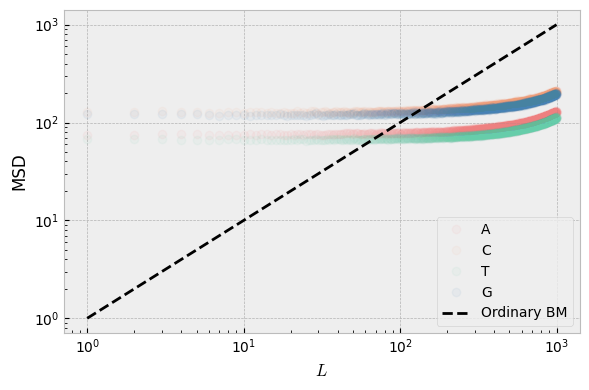

In [ ]:
print('Ordinary BM memory function: y = 2DL where D=0.5')

def msd_bm(L,c):

  # Note: Here, we shift the MSD by an arbitrary constant, c
  return L+c

# initialize array to store parameters
arr_popt_bm = np.zeros([n_samp,1])
arr_pcov_bm = np.zeros([n_samp,1,1])

plt.figure(figsize=(6,4))
for j in range(n_samp):
  plt.plot(xpoints, ypoints[j], 'o',  color=label_colors[j], label=labels[j], alpha=0.05)
plt.plot(xpoints, xpoints, '--', color='k', label='Ordinary BM')
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.xlabel(r"$L$", size=12)
plt.ylabel("MSD", size=12)
#plt.title("MSD: Ordinary BM")
plt.legend()
plt.tight_layout()
plt.show()


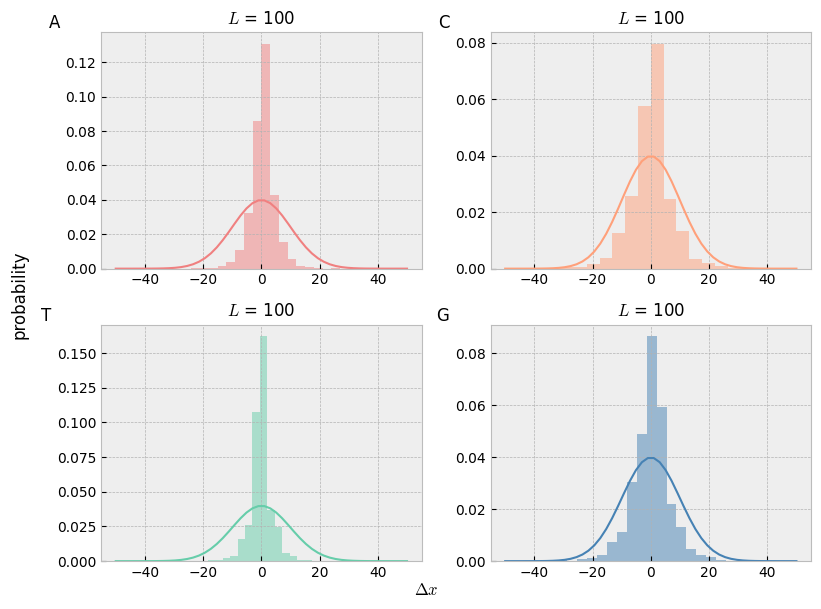

In [ ]:
# set parameters
n_samp=4                                       # no. of samples
tau_vals =np.array([100])            # lag times

# implement code for computation of PDFs for different lag times
nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey = False, figsize=(8,6))
fig.text(-0.02, 0.5, 'probability', va='center', rotation='vertical',size=12)
fig.text(0.5, 0, r'$\Delta x$', ha = 'center', rotation='horizontal',size=12)


for j in range(n_samp):
  for k in range(len(tau_vals)):
    h = j+1
    plt.subplot(nrows,ncols,h)
    x = df[j]
    dx = get_displacements(x, tau_vals[k])
    dx = dx[np.isfinite(dx)]
    plt.hist(dx, bins=20, density=True, color=label_colors[j], alpha=0.5)
    plot_pdf_fbm(dx, tau_vals[k],0.5)
    plt.title(r"$L$ = %.0f" % (tau_vals[k]), size=12)
    if k==0:
      plt.ylabel(labels[j], rotation='horizontal', size=12, loc='top')
plt.tight_layout()
plt.show()

FPTD for ordinary Brownian motion

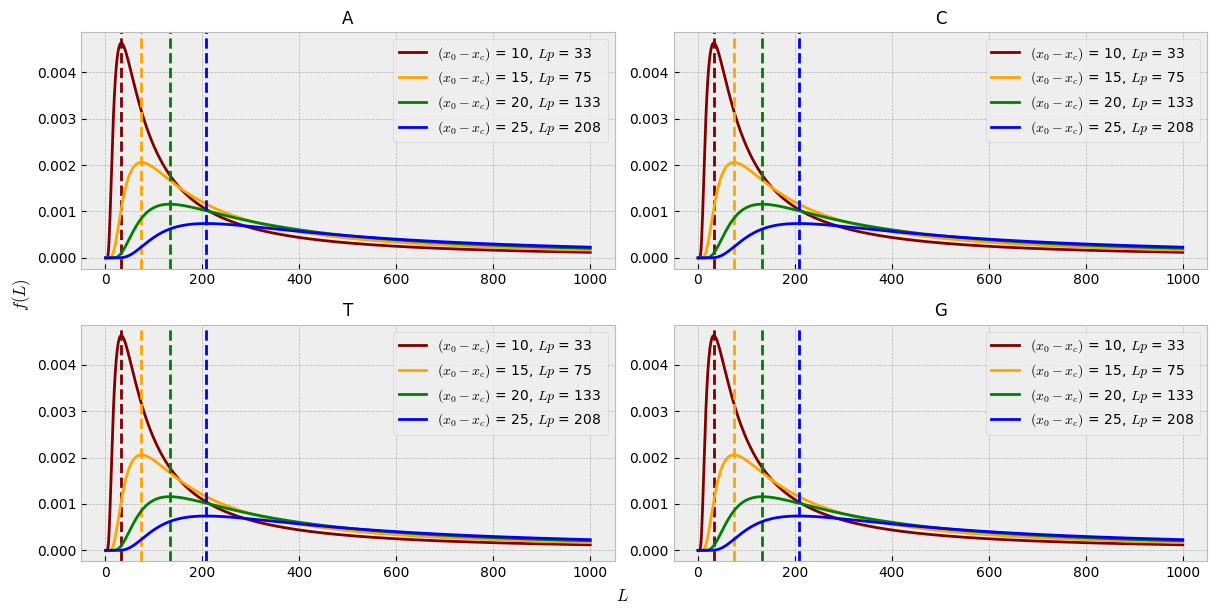

In [ ]:
def fptd_bm(t, dx):
  H = 0.5
  c = H*gamma(H+0.5)**2
  f1 = 2*H*(c/np.pi/t**(2*H+2))**0.5
  f2 = dx
  f3 = np.exp(-1*c*(dx)**2/t**(2*H))
  return f1*f2*f3

Dx = [10, 15, 20, 25]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
colors = ['maroon', 'orange', 'green', 'blue']


nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey=False, figsize=(12,6))
fig.text(-0.01, 0.5, '$f(L)$', va='center', rotation='vertical',size=12)
fig.text(0.5, -0.01, '$L$', ha = 'center', rotation='horizontal',size=12)
for j in range(n_samp):
  plt.subplot(2,2,j+1)
  for k in range(len(Dx)):
    Lpoints = np.linspace(1,1e3,1000)
    fpoints = fptd_bm(Lpoints, Dx[k])
    fpeak = np.argmax(fpoints)
    peak = Lpoints[fpeak]
    plt.plot(Lpoints, fpoints, color=colors[k], linestyle = '-', markersize=5, lw=2, label=str(r"$(x_0-x_c)$ = "+ str(Dx[k])+", " +  str(r"$Lp$ = %.0f" % peak) ))
    plt.axvline(Lpoints[fpeak], ls='--', lw=2, color=colors[k])
  plt.legend()
  plt.title(str(labels[j]), size=12)
plt.tight_layout()
plt.show()



### Fractional Brownian Motion

Memory Function: $$f(L-s) = \frac{(L-s)^{H-1/2}}{\Gamma(H+1/2)}$$

where $0 \leq s \leq L$.

PDF:

$$P(x_L, L; x_0,0)  = \sqrt{\frac{H\Gamma^2(H+\frac{1}{2})}{\pi L^{2H}}}\exp\left(-\frac{H\Gamma^2(H+\frac{1}{2})(x_L-x_0)^2}{L^{2H}}\right)$$

MSD:

$$\text{MSD} = \frac{1}{2H\Gamma^2(H+\frac{1}{2})}L^{2H}$$

FPTD:

\begin{align}
f(t) =& -\frac{(x_0-x_c)}{\sqrt{2\pi \cdot \text{MSD}}}\frac{\partial (\text{MSD})}{\partial L}\exp\left[-\frac{(x_0-x_c)^2}{2\cdot \text{MSD}}\right]\\
=& 2H\sqrt{\frac{H\Gamma(H+1/2)^2}{\pi}}\frac{1}{L^{H+1}}(x_c-x_0)\exp\left[-\frac{H\Gamma(H+1/2)^2(x_c-x_0)^2}{L^{2H}}\right]
\end{align}

MSD for Fractional Brownian Motion

A H,c:  [ 0.27885514 57.96519631]
C H,c:  [  0.31668109 100.        ]
T H,c:  [ 0.26732168 50.06637963]
G H,c:  [ 0.30624775 98.22035315]


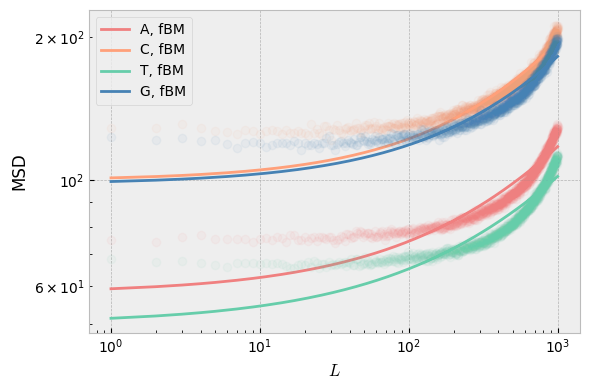

In [ ]:
def msd_fbm(L,H,c):

  # Note: Here, we shift the MSD by an arbitrary constant, c
  return ((L**(2*H))/(2*H*gamma(H+0.5)**2))+c

# initialize array to store parameters
arr_popt_fbm = np.zeros([n_samp,2])
arr_pcov_fbm = np.zeros([n_samp,2,2])

plt.figure(figsize=(6,4))
for j in range(n_samp):
  arr_popt_fbm[j], arr_pcov_fbm[j] = curve_fit(msd_fbm, xpoints, ypoints[j], bounds=([0,-100],[1,100]))
  print(labels[j], 'H,c: ', arr_popt_fbm[j])
  plt.plot(xpoints, msd_fbm(xpoints, *arr_popt_fbm[j]),'-', color=label_colors[j], label = str(labels[j] + ', fBM'))
  plt.plot(xpoints, ypoints[j], 'o',  color=label_colors[j], alpha=0.05)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.xlabel(r"$L$", size=12)
plt.ylabel("MSD", size=12)
#plt.title("MSD: FBM")
plt.legend()
plt.tight_layout()
plt.show()


PDF for Fractional Brownian Motion

<ipython-input-42-7a07b9897c5b>:29: RuntimeWarning: invalid value encountered in multiply
  dx = np.empty((nn))*np.nan


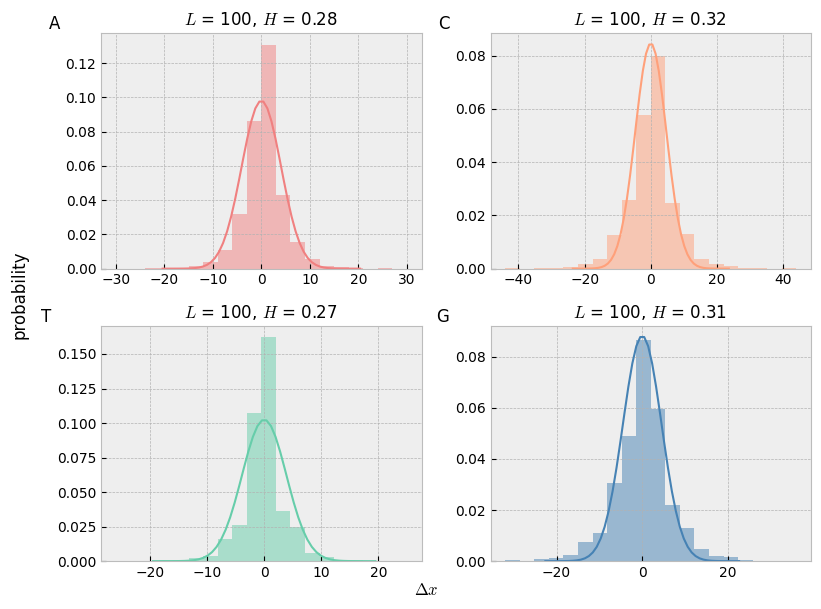

In [ ]:
# implement code for computation of PDFs for different lag times
nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey = False, figsize=(8,6))
fig.text(-0.02, 0.5, 'probability', va='center', rotation='vertical',size=12)
fig.text(0.5, 0, r'$\Delta x$', ha = 'center', rotation='horizontal',size=12)

for j in range(n_samp):
  for k in range(len(tau_vals)):
    h = j+1
    plt.subplot(nrows,ncols,h)
    x = df[j]
    dx = get_displacements(x, tau_vals[k])
    dx = dx[np.isfinite(dx)]
    plt.hist(dx, bins=20, density=True, color=label_colors[j], alpha=0.5)
    plot_pdf_fbm(dx, tau_vals[k],arr_popt_fbm[j][0])
    plt.title(r"$L$ = %.0f, $H$ = %.2f " % (tau_vals[k], arr_popt_fbm[j][0]), size=12)
    if k==0:
      plt.ylabel(labels[j], rotation='horizontal', size=12, loc='top')
plt.tight_layout()
plt.show()

FPTD for fractional Brownian motion

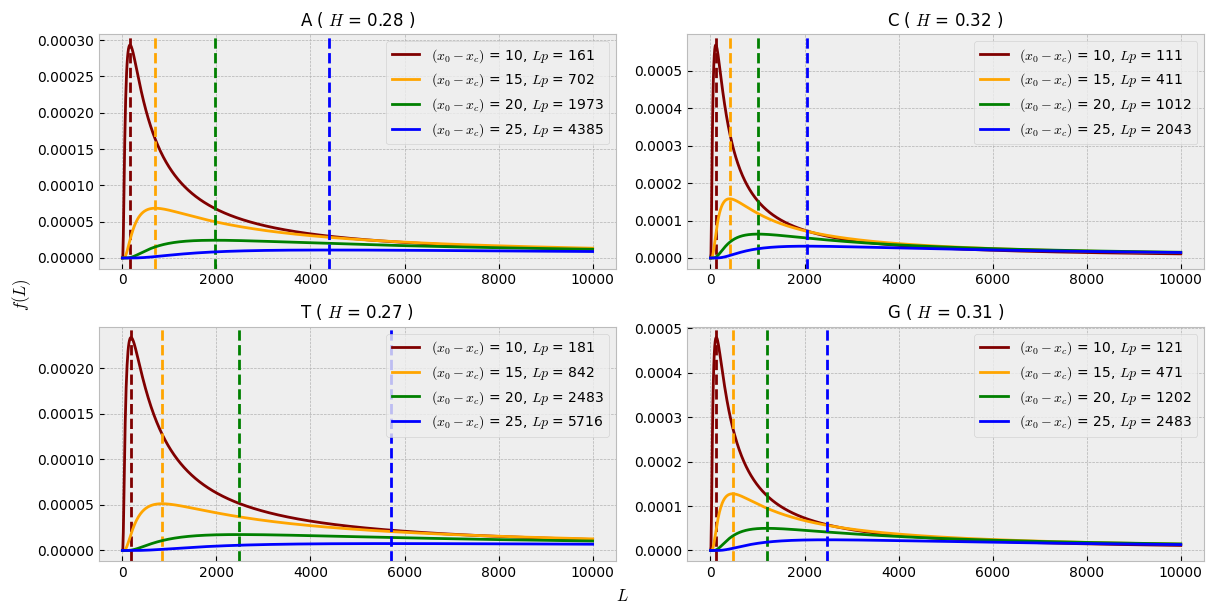

In [ ]:
def fptd_fbm(t, dx, H):
  c = H*gamma(H+0.5)**2
  f1 = 2*H*(c/np.pi/t**(2*H+2))**0.5
  f2 = dx
  f3 = np.exp(-1*c*(dx)**2/t**(2*H))
  return f1*f2*f3

Dx = [10, 15, 20, 25]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
colors = ['maroon', 'orange', 'green', 'blue']


nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey=False, figsize=(12,6))
fig.text(-0.01, 0.5, '$f(L)$', va='center', rotation='vertical',size=12)
fig.text(0.5, -0.01, '$L$', ha = 'center', rotation='horizontal',size=12)
for j in range(n_samp):
  plt.subplot(2,2,j+1)
  for k in range(len(Dx)):
    Lpoints = np.linspace(1,10e3,1000)
    fpoints = fptd_fbm(Lpoints, Dx[k], arr_popt_fbm[j][0])
    fpeak = np.argmax(fpoints)
    peak = Lpoints[fpeak]
    print
    plt.plot(Lpoints, fpoints, color=colors[k], linestyle = '-', markersize=5, lw=2, label=str(r"$(x_0-x_c)$ = "+ str(Dx[k])+", " +  str(r"$Lp$ = %.0f" % peak) ))
    plt.axvline(Lpoints[fpeak], ls='--', lw=2, color=colors[k])
  plt.legend()
  plt.title(str(labels[j] + " ( " + (r"$H$ = %.2f " % (arr_popt_fbm[j][0])) + ")"), size=12)
plt.tight_layout()
plt.show()



### Exponentially modified Brownian motion

Memory Function:

$$f(L-s) = \exp[-(b/2)(L-s)]$$

PDF:

$$P(x_L, L; x_0,0)  = \frac{1}{\sqrt{2\pi [a-c\exp(-bL)]}}\exp\left(\frac{-(x_L-x_0)^2}{2[a-c\exp(-bL)]}\right)$$

MSD:

$$\text{MSD} =  a-ce^{-bL}$$

FPTD:
\begin{align}
f(t) =& -\frac{(x_0-x_c)}{\sqrt{2\pi \cdot \text{MSD}}}\frac{\partial (\text{MSD})}{\partial L}\exp\left[-\frac{(x_0-x_c)^2}{2\cdot \text{MSD}}\right]\\
=& -\frac{(x_0-x_c)}{\sqrt{2\pi[a-ce^{-bL}]}}\cdot(bce^{-bL})\cdot\exp\left[-\frac{(x_0-x_c)^2}{2 [a-ce^{-bL}]}\right]
\end{align}

where $0 \leq s \leq L$.

MSD for exponentially modified Brownian motion

Trial function for MSD: y =a - c*np.exp(-b*L)
A a,b,c:  [ 5.88809607e+01 -1.43388054e-03 -1.68154304e+01]
C a,b,c:  [ 8.72745231e+01 -1.08812692e-03 -4.00515150e+01]
T a,b,c:  [ 5.33245509e+01 -1.51399218e-03 -1.30627792e+01]
G a,b,c:  [ 9.00523382e+01 -1.27806921e-03 -2.97030618e+01]


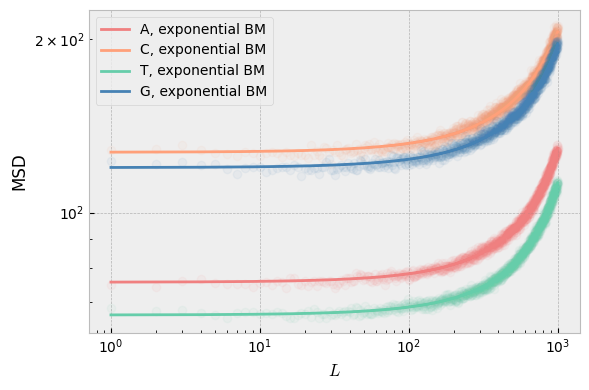

In [ ]:
# Exponential memory function
def msd_func1(x,a,b,c):
  return a - c*np.exp(-b*x)

# initialize array to store parameters
arr_popt = np.zeros([n_samp,3])
arr_pcov = np.zeros([n_samp,3,3])

print('Trial function for MSD: y =a - c*np.exp(-b*L)')
plt.figure(figsize=(6,4))
for j in range(n_samp):
  arr_popt[j], arr_pcov[j] = curve_fit(msd_func1, xpoints, ypoints[j], bounds=([-100,-100,-100],[100,100,100]))
  print(labels[j], 'a,b,c: ', arr_popt[j])
  plt.plot(xpoints, msd_func1(xpoints, *arr_popt[j]),'-', color=label_colors[j], label = str(labels[j] + ', exponential BM'))
  plt.plot(xpoints, ypoints[j], 'o',  color=label_colors[j], alpha=0.05)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.xlabel(r"$L$", size=12)
plt.ylabel("MSD", size=12)
#plt.title("MSD = $a - ce^{-bL}$")
plt.legend()
plt.tight_layout()
plt.show()

PDF for exponentially modified Brownian motion

<ipython-input-42-7a07b9897c5b>:29: RuntimeWarning: invalid value encountered in multiply
  dx = np.empty((nn))*np.nan


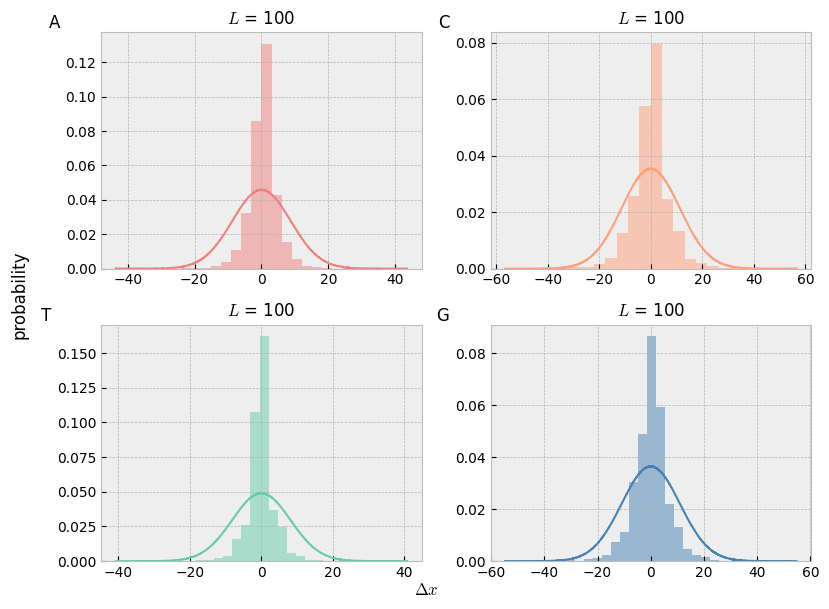

In [ ]:
# Computes and plots PDF corresponding to exponential memory function
def plot_pdf1(dx,a,b,c):

  '''
  inputs: x: dx: displacements (1-d array), tau: lag time (float),
          H: Hurst parameter (float)
  returns: none

  '''

  # Compute msd of fBm
  msd = msd_func1(dx, a, b, c)

  # Generates normalized Gaussian distribution with mean = 0 and sd = sqrt(MSD)
  xx_mean = 0.
  xx_sd = np.sqrt(msd)
  xx = np.linspace(-5, 5, len(dx))*xx_sd # gridded points from -5 to 5 in units of sd
  yy = norm.pdf(xx, xx_mean, xx_sd)

  # Plot Gaussian distribution
  plt.plot(xx, yy, '-', label="theoretical", color=label_colors[j], lw=1.5)
  plt.title(labels[j])
  #plt.legend()

# implement code for computation of PDFs for different lag times
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=False, sharey = False, figsize=(8,6))
fig.text(-0.02, 0.5, 'probability', va='center', rotation='vertical',size=12)
fig.text(0.5, 0, r'$\Delta x$', ha = 'center', rotation='horizontal',size=12)

for j in range(n_samp):
  for k in range(len(tau_vals)):
    h = j+1
    plt.subplot(nrows,ncols,h)
    x = df[j]
    dx = get_displacements(x, tau_vals[k])
    dx = dx[np.isfinite(dx)]
    plt.hist(dx, bins=20, density=True, color=label_colors[j], alpha=0.5)
    plot_pdf1(dx, *arr_popt[j])
    plt.title(r"$L$ = %.0f" % (tau_vals[k]), size=12)
    if k==0:
      plt.ylabel(labels[j], rotation='horizontal', size=12, loc='top')
plt.tight_layout()
plt.show()


FPTD for exponentially modified Brownian motion

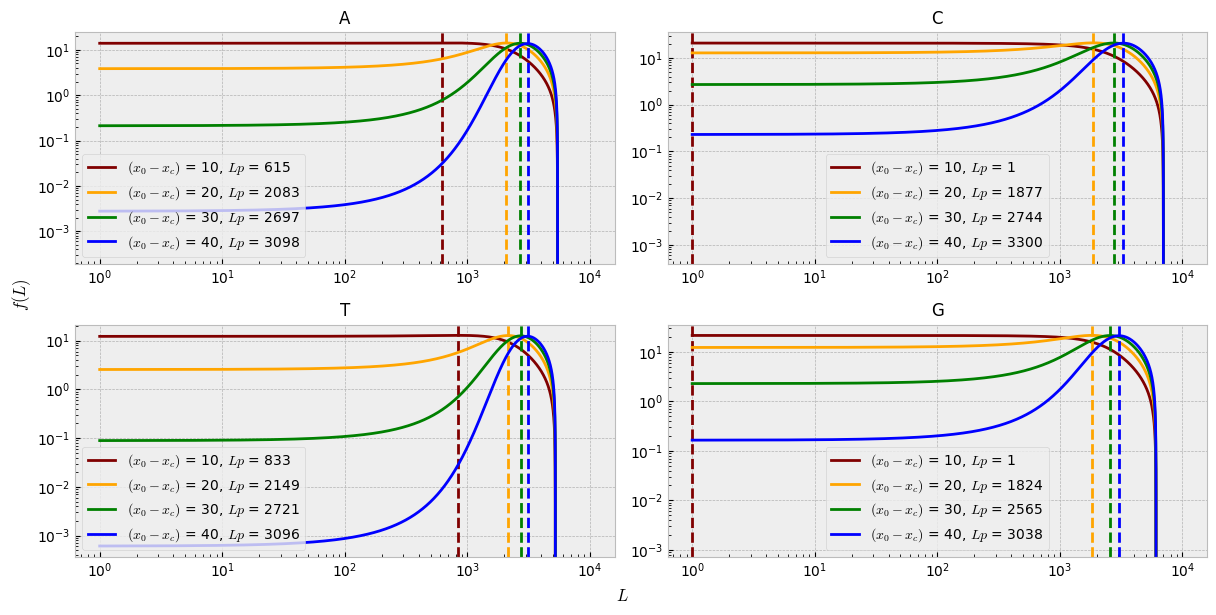

In [ ]:
def fptd_exp(t, dx, a, b, c):
  msd = a-c*np.exp(-b*t)
  f1 = -dx/np.sqrt(2*np.pi*msd)
  f2 = -b*msd-a
  f3 = np.exp(-dx**2/(2*msd))
  return f1*f2*f3

Dx = [10,20,30,40]
linestyles = ['dotted','solid', 'dashed', 'dashdot', 'dotted']
colors = ['maroon', 'orange', 'green', 'blue', 'violet']


nrows=2
ncols=2
fig, ax = plt.subplots(nrows, ncols, sharex=False, sharey=False, figsize=(12,6))
fig.text(-0.01, 0.5, '$f(L)$', va='center', rotation='vertical',size=12)
fig.text(0.5, -0.01, '$L$', ha = 'center', rotation='horizontal',size=12)
for j in range(n_samp):
  plt.subplot(2,2,j+1)
  for k in range(len(Dx)):
    Lpoints = np.linspace(1,1e4,10000)
    fpoints = fptd_exp(Lpoints, Dx[k], *arr_popt[j])
    fpeak = np.argmax(fpoints)
    peak = Lpoints[fpeak]
    plt.plot(Lpoints, fpoints, color=colors[k], linestyle = '-', markersize=5, lw=2, label=str(r"$(x_0-x_c)$ = "+ str(Dx[k])+", " +  str(r"$Lp$ = %.0f" % peak) ))
    plt.axvline(Lpoints[fpeak], ls='--', lw=2, color=colors[k])
    plt.xscale("log")
    plt.yscale("log")
  plt.legend()
  plt.title(str(labels[j]), size=12)
plt.tight_layout()
plt.show()



### Other possible MSD functions via curve-fit

Trial function for MSD: y = aL^b+c
A c:  [5.11259250e-04 1.66557000e+00 7.73135585e+01]
C c:  [3.26034371e-03 1.45412244e+00 1.29137279e+02]
T c:  [2.97793138e-04 1.72218408e+00 6.78569607e+01]
G c:  [1.39466365e-03 1.57273018e+00 1.21907382e+02]


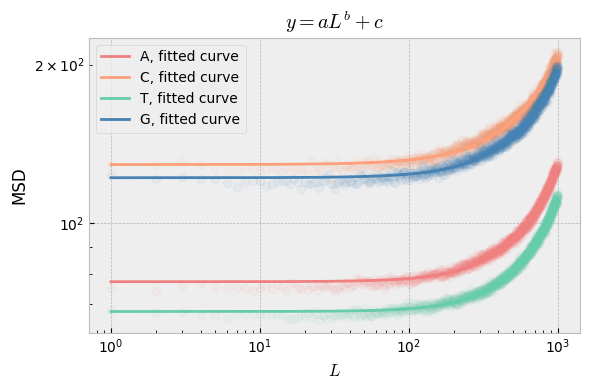

In [ ]:
# Here, I used a curve fit on the MSD data
def msd_func3(x,a,b,c):
  return a*x**b + c

print('Trial function for MSD: y = aL^b+c')
plt.figure(figsize=(6,4))
for j in range(n_samp):
  popt, pcov = curve_fit(msd_func3, xpoints, ypoints[j])
  print(labels[j], 'c: ', popt)
  plt.plot(xpoints, msd_func3(xpoints, *popt),'-', color=label_colors[j], label = str(labels[j] + ', fitted curve'))
  plt.plot(xpoints, ypoints[j], 'o',  color=label_colors[j], alpha=0.05)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.xlabel(r"$L$", size=12)
plt.ylabel("MSD", size=12)
plt.title(r"$y = aL^b+c$")
plt.legend()
plt.tight_layout()
plt.show()

Trial function for MSD: y = aL^2+bL+c
A c:  [3.59924524e-05 1.59885741e-02 7.63568120e+01]
C c:  [3.94450787e-05 3.79284454e-02 1.27625244e+02]
T c:  [3.33427993e-05 1.12774985e-02 6.71564560e+01]
G c:  [4.59836717e-05 2.89447241e-02 1.20437934e+02]


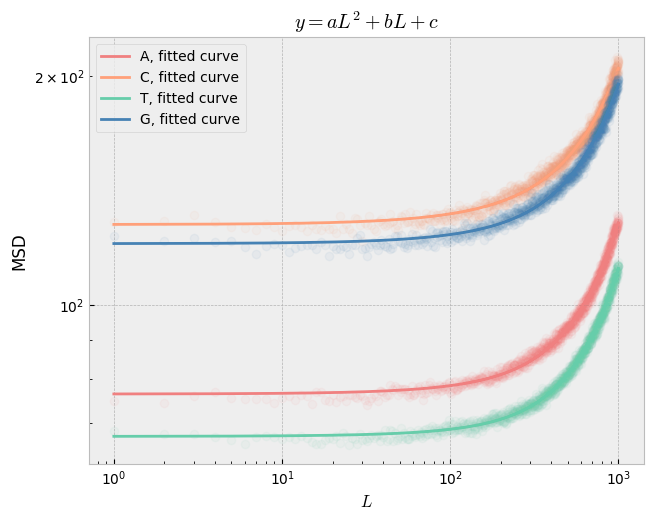

In [ ]:
# Here, I used a curve fit on the MSD data
def msd_func2(x,a,b,c):
  return a*x**2 + b*x + c

print('Trial function for MSD: y = aL^2+bL+c')
for j in range(n_samp):
  popt, pcov = curve_fit(msd_func2, xpoints, ypoints[j], bounds=([-1000,-1000,-1000],[1000,1000,1000]))
  print(labels[j], 'c: ', popt)
  plt.plot(xpoints, msd_func2(xpoints, *popt),'-', color=label_colors[j], label = str(labels[j] + ', fitted curve'))
  plt.plot(xpoints, ypoints[j], 'o',  color=label_colors[j], alpha=0.05)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.xlabel(r"$L$", size=12)
plt.ylabel("MSD", size=12)
plt.title(r"$y = aL^2+bL+c$")
plt.legend()
plt.show()